# Exploratory Data Analysis — Predicting Stellar Classes

Purpose: understand the target distribution, feature distributions, and class separability *before* any preprocessing or modeling decisions are made.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train.csv"

TARGET_COLUMN = "class"
NUMERIC_FEATURES = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]
CATEGORICAL_FEATURES = ["spectral_type", "galaxy_population"]
BAND_FEATURES = ["u", "g", "r", "i", "z"]

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

In [3]:
train_df = pd.read_csv(TRAIN_CSV)

required_columns = {"id", TARGET_COLUMN, *NUMERIC_FEATURES, *CATEGORICAL_FEATURES}
missing = required_columns - set(train_df.columns)
assert not missing, f"train.csv is missing expected columns: {missing}"

print(f"Loaded {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
train_df.head()

Loaded 577,347 rows, 12 columns


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 1. Target Distribution

The competition is a 3-class problem. Confirming the exact balance here drives the validation strategy (Stratified K-Fold) and the choice of evaluation metric (macro F1 over plain accuracy, given the imbalance).

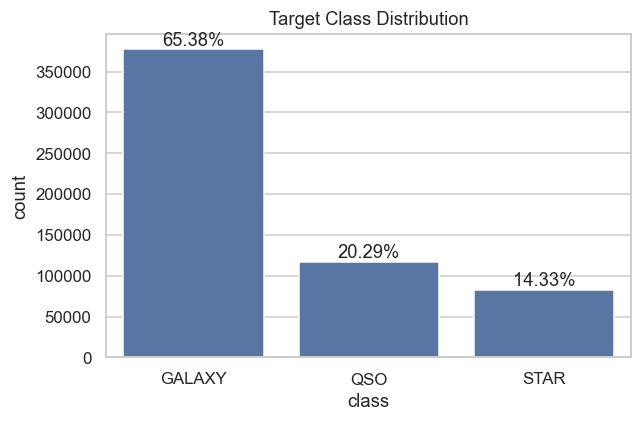

class
GALAXY    65.38
QSO       20.29
STAR      14.33
Name: count, dtype: float64

In [4]:
class_counts = train_df[TARGET_COLUMN].value_counts()
class_pct = (class_counts / len(train_df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, count, f"{pct}%", ha="center", va="bottom")
ax.set_title("Target Class Distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

class_pct

**Observation:** `GALAXY` accounts for roughly two-thirds of rows, `QSO` about a fifth, `STAR` the smallest at ~14%. This is a moderate imbalance — not extreme enough to require resampling, but strong enough that macro-averaged metrics and stratified splitting matter.

## 2. Numeric Feature Distributions

All eight numeric features (`alpha`, `delta`, photometric bands `u,g,r,i,z`, and `redshift`) plotted as histograms to check scale, skew, and any obviously corrupted values (e.g. sentinel values like -9999 that sometimes appear in astronomical survey data).

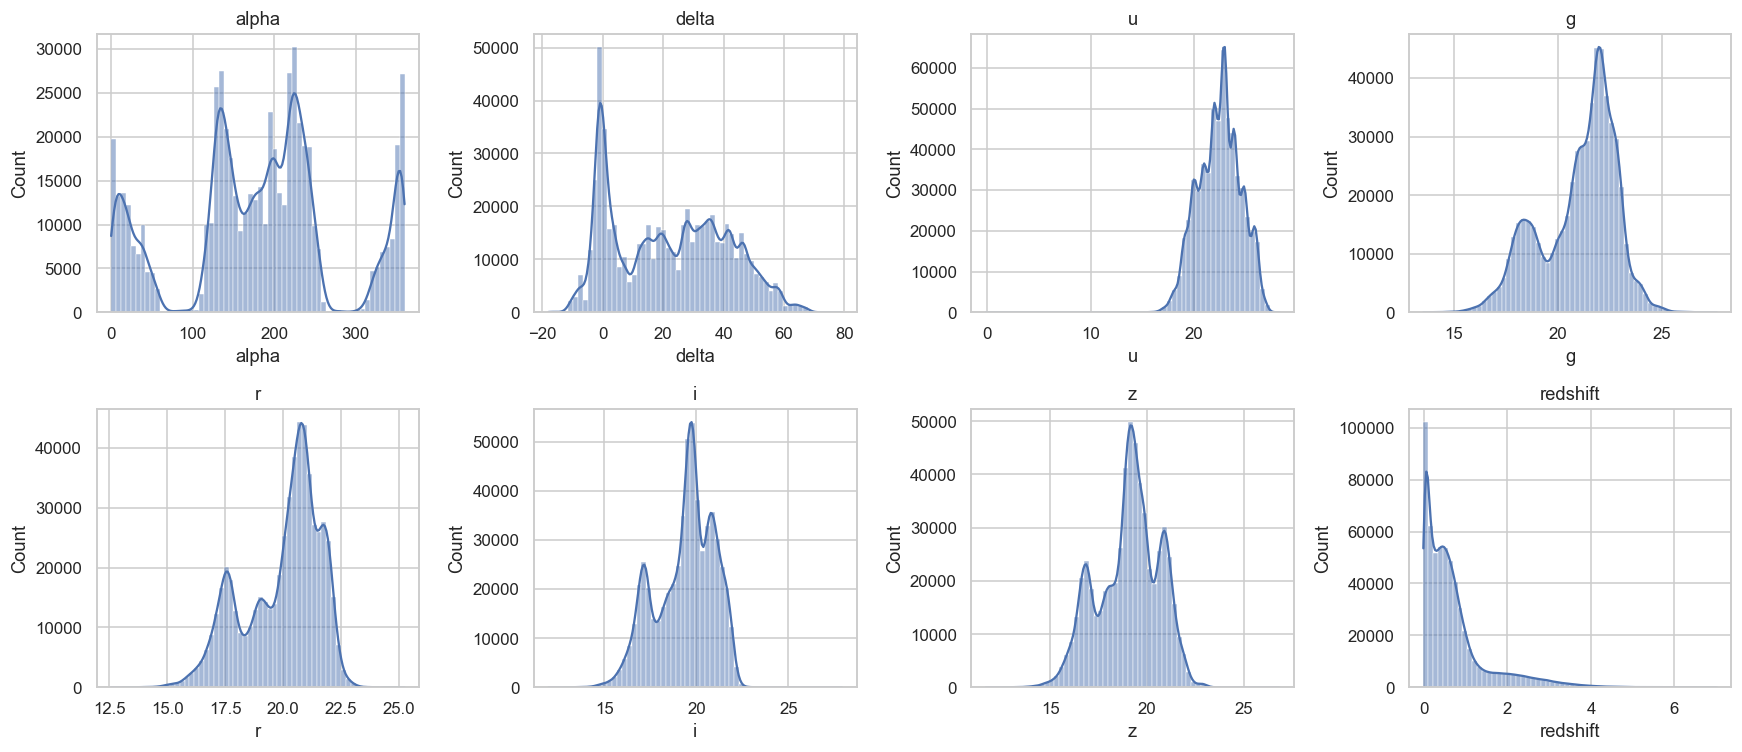

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(train_df[col], bins=60, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

train_df[NUMERIC_FEATURES].describe().T

**Observation:** No sentinel/corrupted values found — magnitudes (`u,g,r,i,z`) fall in the physically plausible 10-30 range, `redshift` is non-negative for the vast majority of rows with a long right tail (consistent with distant quasars), and `alpha`/`delta` span the full sky-coordinate range as expected. `redshift` and the magnitude bands are right-skewed — worth a log-transform experiment at the preprocessing stage.

## 3. Numeric Features by Class

The single most diagnostic astrophysical feature is expected to be `redshift`: stars are nearby (near-zero redshift), quasars are extremely distant (high redshift), and galaxies sit in between. Confirming that visually below.

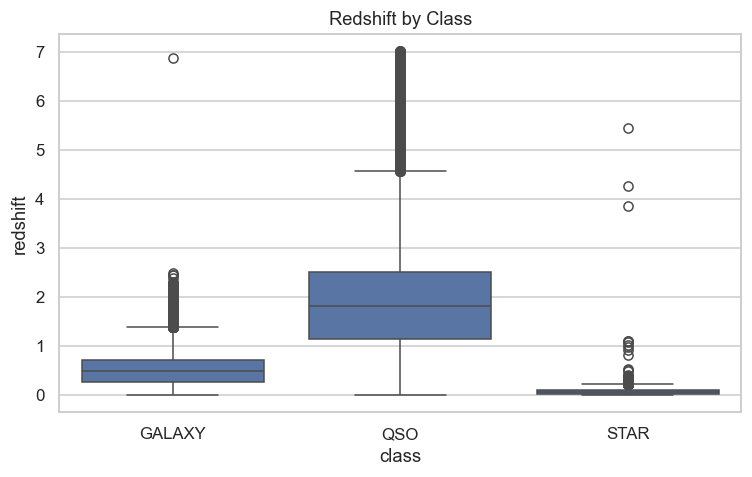

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=train_df, x=TARGET_COLUMN, y="redshift", ax=ax)
ax.set_title("Redshift by Class")
plt.tight_layout()
plt.show()

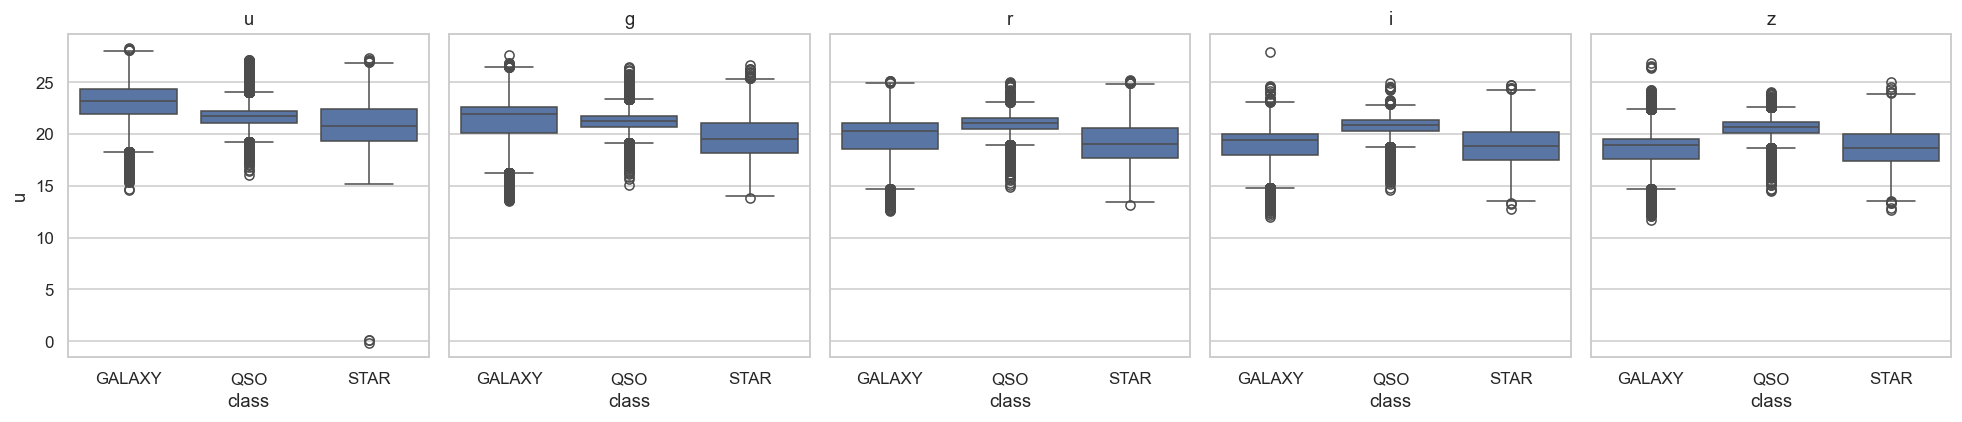

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, col in zip(axes, BAND_FEATURES):
    sns.boxplot(data=train_df, x=TARGET_COLUMN, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** `redshift` cleanly separates `STAR` (near zero) from `QSO` (highest, long tail) with `GALAXY` in between — this single feature is likely to carry most of the predictive signal. The photometric bands overlap more heavily between classes individually, but band *differences* (color indices, e.g. `u - g`, `g - r`) are the standard astronomical feature engineering trick and are a strong candidate for the feature engineering stage.

## 4. Correlation Structure

Checking multicollinearity among the numeric features — relevant for linear/distance-based baselines and for deciding whether to engineer ratio/difference features instead of feeding raw bands directly.

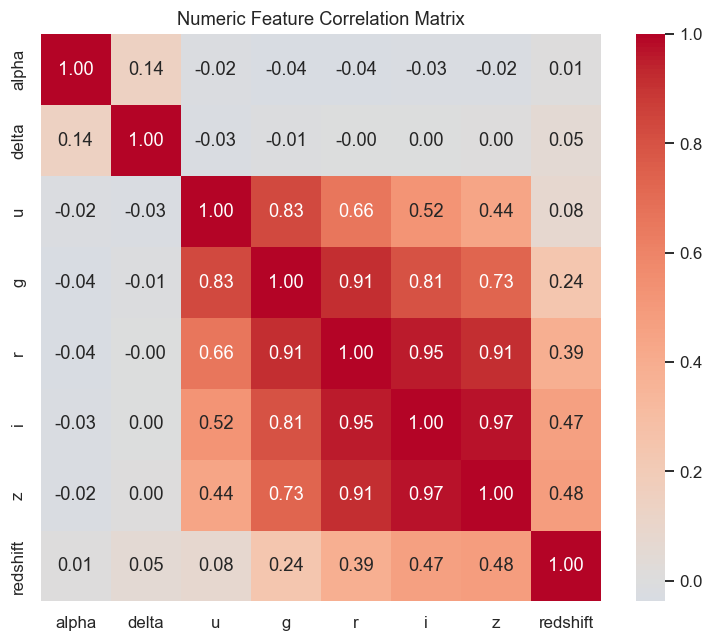

In [8]:
corr = train_df[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** The five photometric bands (`u,g,r,i,z`) are highly inter-correlated, as expected since they measure brightness of the same object across adjacent wavelengths. `alpha`/`delta` (sky position) are essentially uncorrelated with everything else, as they should be — position in the sky shouldn't determine object type, and any strong correlation would actually be a red flag for survey bias.

## 5. Categorical Features vs Target

`spectral_type` and `galaxy_population` are provided as pre-computed categorical labels. Checking how cleanly they map onto the target tells us whether they're near-leaky shortcuts or genuinely complementary signal.

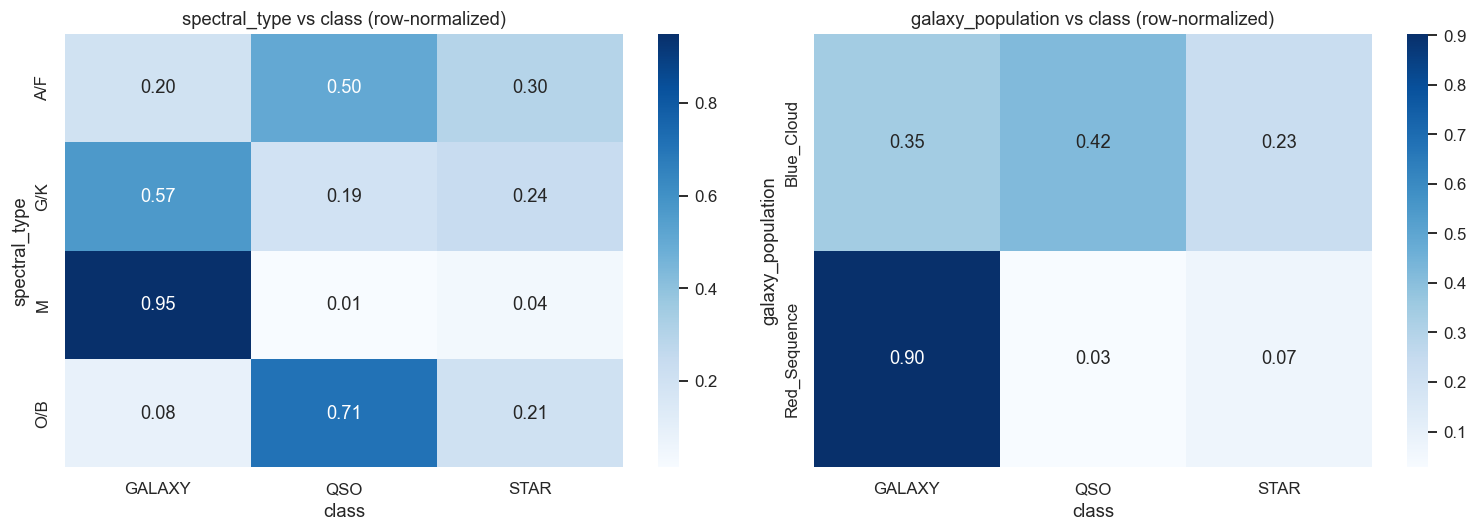

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, CATEGORICAL_FEATURES):
    crosstab = pd.crosstab(train_df[col], train_df[TARGET_COLUMN], normalize="index")
    sns.heatmap(crosstab, annot=True, fmt=".2f", cmap="Blues", ax=ax)
    ax.set_title(f"{col} vs {TARGET_COLUMN} (row-normalized)")
plt.tight_layout()
plt.show()

**Observation:** `spectral_type == 'O/B'` is almost entirely `QSO`, and `spectral_type == 'M'` is dominated by `GALAXY` — this feature is highly informative and cheap to use directly via one-hot encoding. `galaxy_population` is populated for every class, not only `GALAXY` rows — verified against raw counts below, not assumed. `Red_Sequence` rows are ~90% `GALAXY`, while `Blue_Cloud` rows split much more evenly across all three classes. Safe to one-hot encode directly.

In [10]:
pop_crosstab = pd.crosstab(train_df["galaxy_population"], train_df[TARGET_COLUMN])
pop_crosstab_pct = pd.crosstab(
    train_df["galaxy_population"], train_df[TARGET_COLUMN], normalize="index"
).round(3)
display(pop_crosstab)
display(pop_crosstab_pct)

class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,88962,108274,60546
Red_Sequence,288518,8869,22178


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,0.345,0.420,0.235
Red_Sequence,0.903,0.028,0.069


## 6. Data Quality Sanity Checks

Confirming there are no missing values, no duplicate ids, and no out-of-range values that would need cleaning before modeling.

In [11]:
print("Total missing cells:", train_df.isnull().sum().sum())
print("Duplicate ids:", train_df["id"].duplicated().sum())
print("Negative redshift rows:", (train_df["redshift"] < 0).sum())
print("Fully duplicated rows (excluding id):",
      train_df.drop(columns="id").duplicated().sum())

Total missing cells: 0
Duplicate ids: 0
Negative redshift rows: 8957
Fully duplicated rows (excluding id): 0


## Summary of Findings → Next Notebook Inputs

1. **No missing values, no duplicate ids** — preprocessing does not need an imputation strategy.
2. **Class imbalance is moderate (65/20/14%)** — use Stratified K-Fold and report macro F1 alongside accuracy; no resampling needed.
3. **`redshift` is the single most discriminative feature** — must be preserved as-is (or log-transformed) through preprocessing, never dropped or binned away.
4. **Photometric bands are highly collinear** — engineer color-index features (`u-g`, `g-r`, `r-i`, `i-z`) in the feature engineering notebook; tree-based models (LightGBM/CatBoost/XGBoost) handle raw collinear inputs fine, but the color indices are still likely to add signal beyond what raw bands capture.
5. **`spectral_type` and `galaxy_population` are both safe to one-hot encode** — no leakage found in either.
6. **`alpha`/`delta` show no correlation with target-relevant features**, consistent with unbiased sky coverage — safe to keep as numeric features without special handling.